## 1. Install Dependencies


In [1]:
import sys
!{sys.executable} -m pip install librosa==0.11.0 tqdm scikit-learn numpy pandas matplotlib seaborn --quiet



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports and Setup


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Reproducibility 
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Audio parameters 
SR      = 22050
N_MELS  = 128
N_FFT   = 2048
HOP_LEN = 512
FMIN    = 20
FMAX    = 8000
N_MFCC  = 40

# Class list
CLASSES = [
    'bus', 'busystreet', 'office', 'openairmarket', 'park',
    'quietstreet', 'restaurant', 'supermarket', 'tube', 'tubestation'
]
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASSES)}

# Output folder
OUTPUT_DIR = 'output_block1'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Setup complete.')
print(f'Audio params: SR={SR}, N_MELS={N_MELS}, N_FFT={N_FFT}, HOP_LEN={HOP_LEN}')
print(f'MFCC coefficients: {N_MFCC}')


Setup complete.
Audio params: SR=22050, N_MELS=128, N_FFT=2048, HOP_LEN=512
MFCC coefficients: 40


## 3. Load Annotations from Block 1




In [3]:
csv_path = os.path.join(OUTPUT_DIR, 'dcase2013_annotations.csv')
df = pd.read_csv(csv_path)

print(f'Annotations loaded: {len(df)} files')
print(df.head())


Annotations loaded: 100 files
    filename                                           filepath label  \
0  bus01.wav  C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Inte...   bus   
1  bus02.wav  C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Inte...   bus   
2  bus03.wav  C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Inte...   bus   
3  bus04.wav  C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Inte...   bus   
4  bus05.wav  C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Inte...   bus   

   label_idx  
0          0  
1          0  
2          0  
3          0  
4          0  


## 4. Preprocessing Pipeline



In [ ]:
def preprocess_audio(filepath, sr=SR):
    """
    Load and preprocess a single audio file.
    Steps: resample → mono → peak normalize.
    """
    wav, sr_out = librosa.load(filepath, sr=sr, mono=True)
    wav = wav / (np.max(np.abs(wav)) + 1e-9)
    return wav, sr_out


# Quick test on one file 
test_path = df.iloc[0]['filepath']
wav_test, sr_test = preprocess_audio(test_path)

print(f'File            : {df.iloc[0]["filename"]}')
print(f'Waveform shape  : {wav_test.shape}')
print(f'Sample rate     : {sr_test} Hz')
print(f'Duration        : {len(wav_test)/sr_test:.2f} s')
print(f'Amplitude range : [{wav_test.min():.4f}, {wav_test.max():.4f}]')


File            : bus01.wav
Waveform shape  : (661500,)
Sample rate     : 22050 Hz
Duration        : 30.00 s
Amplitude range : [-0.9946, 1.0000]


## 5. Feature Extraction Functions




In [5]:
def extract_logmel_features(wav, sr=SR):
    """
    Extract Log-Mel Spectrogram statistics.
    Returns feature vector of shape (N_MELS*2,) = (256,)
    """
    mel_spec = librosa.feature.melspectrogram(
        y=wav, sr=sr,
        n_mels=N_MELS, n_fft=N_FFT,
        hop_length=HOP_LEN, fmin=FMIN, fmax=FMAX
    )
    log_mel = librosa.power_to_db(mel_spec, ref=np.max)
    return np.concatenate([np.mean(log_mel, axis=1), np.std(log_mel, axis=1)])


def extract_mfcc_features(wav, sr=SR):
    """
    Extract MFCC statistics.
    Returns feature vector of shape (N_MFCC*2,) = (80,)
    """
    mfcc = librosa.feature.mfcc(
        y=wav, sr=sr,
        n_mfcc=N_MFCC, n_fft=N_FFT,
        hop_length=HOP_LEN, fmin=FMIN, fmax=FMAX
    )
    return np.concatenate([np.mean(mfcc, axis=1), np.std(mfcc, axis=1)])


# ── Quick test ────────────────────────────────────────────────────────────────
logmel_vec = extract_logmel_features(wav_test)
mfcc_vec   = extract_mfcc_features(wav_test)

print(f'Log-Mel feature vector shape : {logmel_vec.shape}  (expected: 256)')
print(f'MFCC feature vector shape    : {mfcc_vec.shape}   (expected: 80)')


Log-Mel feature vector shape : (256,)  (expected: 256)
MFCC feature vector shape    : (80,)   (expected: 80)


## 6. Extract Features for All Files




In [6]:
def extract_all_features(df):
    X_logmel, X_mfcc, y = [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Extracting features'):
        wav, sr = preprocess_audio(row['filepath'])
        X_logmel.append(extract_logmel_features(wav, sr))
        X_mfcc.append(extract_mfcc_features(wav, sr))
        y.append(row['label_idx'])
    return np.array(X_logmel), np.array(X_mfcc), np.array(y)


X_logmel, X_mfcc, y = extract_all_features(df)

print(f'\nExtraction complete.')
print(f'X_logmel shape : {X_logmel.shape}  — (files, 256 features)')
print(f'X_mfcc shape   : {X_mfcc.shape}   — (files, 80 features)')
print(f'y shape        : {y.shape}')
print(f'Label distribution: {np.bincount(y)}')


Extracting features: 100%|██████████| 100/100 [00:07<00:00, 12.63it/s]


Extraction complete.
X_logmel shape : (100, 256)  — (files, 256 features)
X_mfcc shape   : (100, 80)   — (files, 80 features)
y shape        : (100,)
Label distribution: [10 10 10 10 10 10 10 10 10 10]


## 7. Train / Validation Split (Stratified 80/20)




In [7]:
X_logmel_train, X_logmel_val, y_train, y_val = train_test_split(
    X_logmel, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_mfcc_train, X_mfcc_val, _, _ = train_test_split(
    X_mfcc, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('Train / Validation split (stratified 80/20):')
print(f'  X_logmel_train : {X_logmel_train.shape}')
print(f'  X_logmel_val   : {X_logmel_val.shape}')
print(f'  X_mfcc_train   : {X_mfcc_train.shape}')
print(f'  X_mfcc_val     : {X_mfcc_val.shape}')
print(f'  y_train dist   : {np.bincount(y_train)}')
print(f'  y_val dist     : {np.bincount(y_val)}')


Train / Validation split (stratified 80/20):
  X_logmel_train : (80, 256)
  X_logmel_val   : (20, 256)
  X_mfcc_train   : (80, 80)
  X_mfcc_val     : (20, 80)
  y_train dist   : [8 8 8 8 8 8 8 8 8 8]
  y_val dist     : [2 2 2 2 2 2 2 2 2 2]


## 8. Feature Normalization 




In [8]:
scaler_logmel = StandardScaler()
X_logmel_train_sc = scaler_logmel.fit_transform(X_logmel_train)
X_logmel_val_sc   = scaler_logmel.transform(X_logmel_val)

scaler_mfcc = StandardScaler()
X_mfcc_train_sc = scaler_mfcc.fit_transform(X_mfcc_train)
X_mfcc_val_sc   = scaler_mfcc.transform(X_mfcc_val)

print('Normalization applied.')
print(f'Log-Mel train — mean: {X_logmel_train_sc.mean():.4f}, std: {X_logmel_train_sc.std():.4f}')
print(f'MFCC train    — mean: {X_mfcc_train_sc.mean():.4f}, std: {X_mfcc_train_sc.std():.4f}')


Normalization applied.
Log-Mel train — mean: 0.0000, std: 1.0000
MFCC train    — mean: 0.0000, std: 1.0000


## 9. Feature Visualization


### 9.1 Mean Log-Mel profile per class


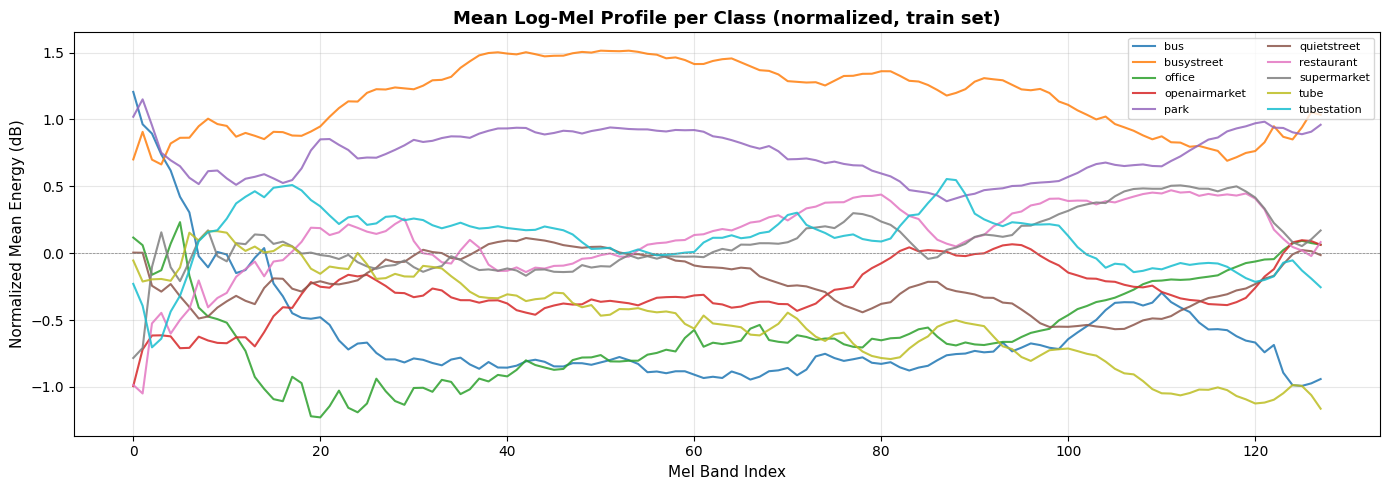

Saved: output_block1\logmel_mean_profiles.png


In [9]:
colors = plt.cm.tab10(np.linspace(0, 1, len(CLASSES)))
fig, ax = plt.subplots(figsize=(14, 5))

for idx, cls in enumerate(CLASSES):
    mask = y_train == idx
    if mask.sum() == 0:
        continue
    mean_profile = X_logmel_train_sc[mask, :N_MELS].mean(axis=0)
    ax.plot(mean_profile, label=cls, color=colors[idx], linewidth=1.5, alpha=0.85)

ax.set_title('Mean Log-Mel Profile per Class (normalized, train set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mel Band Index', fontsize=11)
ax.set_ylabel('Normalized Mean Energy (dB)', fontsize=11)
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.grid(True, alpha=0.3)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, 'logmel_mean_profiles.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')


### 9.2 Mean MFCC profile per class


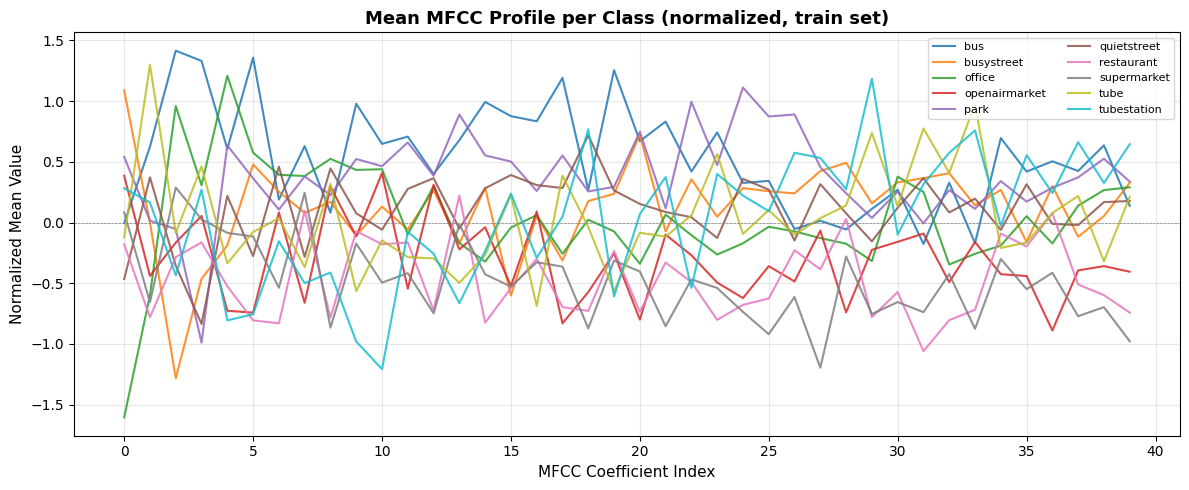

Saved: output_block1\mfcc_mean_profiles.png


In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

for idx, cls in enumerate(CLASSES):
    mask = y_train == idx
    if mask.sum() == 0:
        continue
    mean_profile = X_mfcc_train_sc[mask, :N_MFCC].mean(axis=0)
    ax.plot(mean_profile, label=cls, color=colors[idx], linewidth=1.5, alpha=0.85)

ax.set_title('Mean MFCC Profile per Class (normalized, train set)', fontsize=13, fontweight='bold')
ax.set_xlabel('MFCC Coefficient Index', fontsize=11)
ax.set_ylabel('Normalized Mean Value', fontsize=11)
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.grid(True, alpha=0.3)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, 'mfcc_mean_profiles.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')


### 9.3 Feature Heatmap (Log-Mel, train set sorted by class)


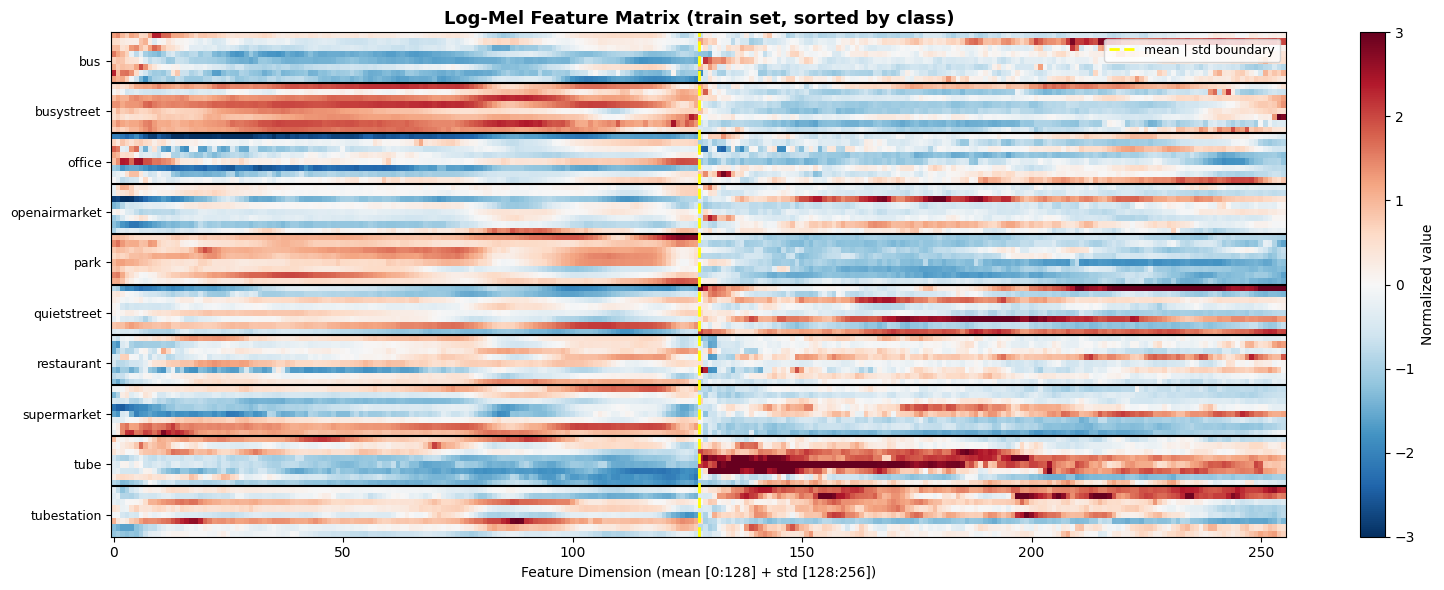

Saved: output_block1\logmel_feature_heatmap.png


In [11]:
sort_idx = np.argsort(y_train)
X_sorted = X_logmel_train_sc[sort_idx]
y_sorted = y_train[sort_idx]

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(X_sorted, aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3)

class_boundaries = np.where(np.diff(y_sorted))[0] + 1
for b in class_boundaries:
    ax.axhline(b - 0.5, color='black', linewidth=1.5)

class_centers = []
prev = 0
for b in np.append(class_boundaries, len(y_sorted)):
    class_centers.append((prev + b) / 2)
    prev = b
ax.set_yticks(class_centers)
ax.set_yticklabels(CLASSES, fontsize=9)

ax.set_title('Log-Mel Feature Matrix (train set, sorted by class)', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Dimension (mean [0:128] + std [128:256])', fontsize=10)
ax.axvline(N_MELS - 0.5, color='yellow', linewidth=2, linestyle='--', label='mean | std boundary')
ax.legend(loc='upper right', fontsize=9)
fig.colorbar(im, ax=ax, label='Normalized value')
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, 'logmel_feature_heatmap.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')


## 10. Save All Features and Scalers




In [12]:
import pickle

np.savez(
    os.path.join(OUTPUT_DIR, 'features_logmel.npz'),
    X_train=X_logmel_train_sc,
    X_val=X_logmel_val_sc,
    y_train=y_train,
    y_val=y_val,
    X_train_raw=X_logmel_train,
    X_val_raw=X_logmel_val
)

np.savez(
    os.path.join(OUTPUT_DIR, 'features_mfcc.npz'),
    X_train=X_mfcc_train_sc,
    X_val=X_mfcc_val_sc,
    y_train=y_train,
    y_val=y_val
)

with open(os.path.join(OUTPUT_DIR, 'scaler_logmel.pkl'), 'wb') as f:
    pickle.dump(scaler_logmel, f)

with open(os.path.join(OUTPUT_DIR, 'scaler_mfcc.pkl'), 'wb') as f:
    pickle.dump(scaler_mfcc, f)

np.savez(
    os.path.join(OUTPUT_DIR, 'features_full_unscaled.npz'),
    X_logmel=X_logmel,
    X_mfcc=X_mfcc,
    y=y
)

print('All files saved to', OUTPUT_DIR)
print('  features_logmel.npz')
print('  features_mfcc.npz')
print('  scaler_logmel.pkl')
print('  scaler_mfcc.pkl')
print('  features_full_unscaled.npz')


All files saved to output_block1
  features_logmel.npz
  features_mfcc.npz
  scaler_logmel.pkl
  scaler_mfcc.pkl
  features_full_unscaled.npz


## 11. Feature Summary for Project Report


In [13]:
print('=' * 60)
print('BLOCK 2 — FEATURE EXTRACTION SUMMARY')
print('=' * 60)
print()
print('PREPROCESSING')
print(f'  Resampling        : 44100 Hz → {SR} Hz')
print(f'  Channel handling  : Stereo (binaural) → Mono (mean)')
print(f'  Normalization     : Peak normalization to [-1, 1]')
print()
print('FEATURE EXTRACTION')
print(f'  FFT window (n_fft)   : {N_FFT} samples = {N_FFT/SR*1000:.1f} ms')
print(f'  Hop length           : {HOP_LEN} samples = {HOP_LEN/SR*1000:.1f} ms')
print(f'  Frequency range      : {FMIN} – {FMAX} Hz')
print()
print('  Log-Mel Spectrogram:')
print(f'    Mel bands          : {N_MELS}')
print(f'    Feature vector     : {N_MELS*2} dimensions')
print()
print('  MFCC:')
print(f'    Coefficients       : {N_MFCC}')
print(f'    Feature vector     : {N_MFCC*2} dimensions')
print()
print('DATASET SPLIT')
print(f'  Strategy           : Stratified random split')
print(f'  Train              : {len(y_train)} files ({len(y_train)/len(y)*100:.0f}%)')
print(f'  Validation         : {len(y_val)} files ({len(y_val)/len(y)*100:.0f}%)')
print(f'  Random state       : {RANDOM_STATE}')
print('=' * 60)


BLOCK 2 — FEATURE EXTRACTION SUMMARY

PREPROCESSING
  Resampling        : 44100 Hz → 22050 Hz
  Channel handling  : Stereo (binaural) → Mono (mean)
  Normalization     : Peak normalization to [-1, 1]

FEATURE EXTRACTION
  FFT window (n_fft)   : 2048 samples = 92.9 ms
  Hop length           : 512 samples = 23.2 ms
  Frequency range      : 20 – 8000 Hz

  Log-Mel Spectrogram:
    Mel bands          : 128
    Feature vector     : 256 dimensions

  MFCC:
    Coefficients       : 40
    Feature vector     : 80 dimensions

DATASET SPLIT
  Strategy           : Stratified random split
  Train              : 80 files (80%)
  Validation         : 20 files (20%)
  Random state       : 42
